In [73]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
# with the code above, I can keep working in notebooks while I modify function in .py file

# Session6
Today, we are going to learn packaging:
* First we have to learn what is function in python
* Make my own function 
* Learn how to do python packaging configuration
* Load the environment in notebook and use the package

Note: This notebook is copied and modified from session4

## Open the file
Since we moved all the notebooks to another directory, I have to change data paths

In [42]:
!pwd # check current working directory so that you can commit the path when opening a file

/home/shch14/spaceMed2026/shch14/notebook


In [43]:
aFile = open ('/home/shch14/spaceMed2026/shch14/data/pulse_data.csv', 'r') # you can type the whole path

In [44]:
aFile = open ('../data/pulse_data.csv', 'r') # or just type ..

## Function

In [45]:
def sum_prod (a,b,c=1):
    return c*(a+b)

In [48]:
sum_prod(1,2) #a=1, b=2

3

In [49]:
sum_prod(c=3,a=4,b=5) #you can change the order

27

In [50]:
sum_prod(c=3,4,5) #it should be error because we didn't assign variables a and b

SyntaxError: positional argument follows keyword argument (3395858934.py, line 1)

In [51]:
name = "Mark"
age = "young"

In [52]:
print(name,age) #print is a sophisticated function which have different arguments

Mark young


In [53]:
print(name, age, sep=" is ") # assign the seperater

Mark is young


In [54]:
print(name, age, sep=" is ", end=".") # assign the end

Mark is young.

## Exercise
* move the data loader to a function called read_pulse
* move the peak finding code to a function called
find_peaks
* move the heart rate calculation to a function called
calc_heart_rate
* and use those functions in the notebook

In [55]:
def read_pulse(file_name):
    aFile = open (file_name, 'r')
    aFile.readline()
    # read it so that we skip the firt line (or start the loop from second line)
    time = []
    absorption = []
    for line in aFile.readlines():
        line = line.split(",")
        time.append(float(line[0]))
        absorption.append(float(line[1]))
    for i in range(10):
        print(time[i], absorption[i]) # I should return time and absorption!


In [56]:
read_pulse('../data/pulse_data.csv')

25.34206948640483 1388.0
25.344574881312038 1388.0
25.347080276219245 1385.0
25.349585671126455 1383.0
25.352091066033662 1383.0
25.35459646094087 1378.0
25.357101855848075 1378.0
25.359607250755285 1375.0
25.362112645662492 1375.0
25.3646180405697 1373.0


In [57]:
#answer
def readPulse(fname):
    dataFile = open (fname, 'r')
    dataFile.readline()
    time = []
    absorption = []
    for line in dataFile.readlines():
        line = line.split(",")
        time.append(float(line[0]))
        absorption.append(float(line[1]))
        
    return time, absorption

In [58]:
time, absorption = readPulse('../data/pulse_data.csv')

In [59]:
def findPeaks(time, absorption, w=50):
    w = w
    peaks = []
    for i in range(len(absorption)):
      start = max(i-w, 0)
      end = min(i+w, len(absorption))
      window = absorption[start:end]
      max_pos = numpy.argmax(window) + start
      if i == max_pos:
        peaks.append(i)
    return peaks

In [60]:
peaks = find_peaks(time, absorption)

In [61]:
def calc_heart_rate(time, peaks):
    time = numpy.array(time)
    time_peaks = time[peaks]
    delta_t = time_peaks[1:] - time_peaks[:-1]
    hr = 60 / delta_t
    return hr

In [62]:
hr = calc_heart_rate(time, peaks)

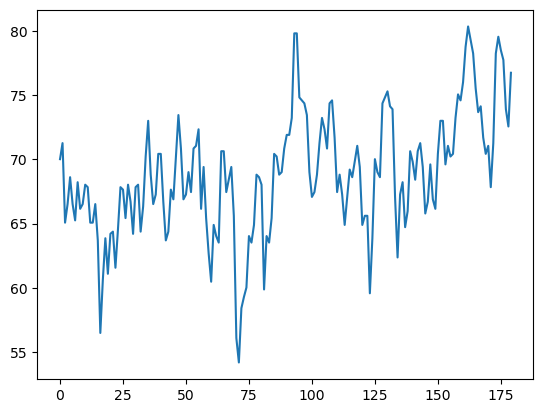

In [63]:
pyplot.plot(hr)
pyplot.show()

## Use my spacemed fucntion!

In [64]:
import spacemed

In [65]:
spacemed.__version__

'0.0.1'

In [66]:
time, absorption = spacemed.readPulse('../data/pulse_data.csv')

In [67]:
Peaks = spacemed.findPeaks(time, absorption)

In [68]:
hr = spacemed.calHR(time, peaks)

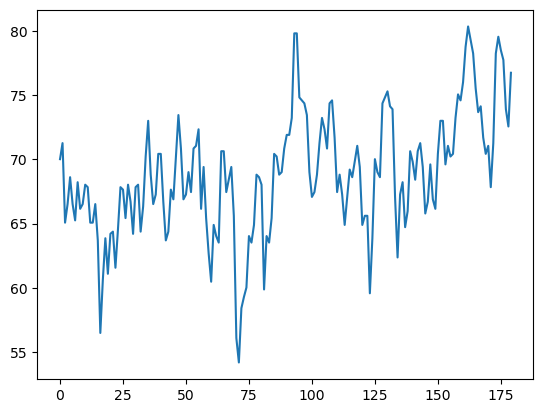

In [69]:
pyplot.plot(hr)